# Teaching Ratings

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/Data_Science_Fundamentals_with_Python_and_SQL_Specialization/portfolio-1.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective**: Analyze the evaluation of professors with different characteristics and determine whether there are external influences on their teaching evaluation scores.

## Import libraries

In [1]:
from scipy.stats import norm, levene, ttest_ind, f_oneway, chi2_contingency, pearsonr
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

## Load the dataset

In [2]:
file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv'
df = pd.read_csv(file_url).loc[:, :"prof"]
df.head()

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2


## Understand the dataset

| Variable    | Description                                                                                                                                          |
| ----------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| minority    | Does the instructor belong to a minority (non-Caucasian) group?                                                                                      |
| age         | The instructor's age                                                                                                                                  |
| gender      | Indicating whether the instructor was male or female.                                                                                                |
| credits     | Is the course a single-credit elective?                                                                                                              |
| beauty      | Rating of the instructor's physical appearance by a panel of six students averaged across the six panelists and standardized to have a mean of zero. |
| eval        | Course overall teaching evaluation score, on a scale of 1 (very unsatisfactory) to 5 (excellent).                                                    |
| division    | Is the course an upper or lower division course?                                                                                                     |
| native      | Is the instructor a native English speaker?                                                                                                          |
| tenure      | Is the instructor on a tenure track?                                                                                                                 |
| students    | Number of students that participated in the evaluation.                                                                                              |
| allstudents | Number of students enrolled in the course.                                                                                                           |
| prof        | Indicating instructor identifier.                                                                                                                    |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   minority     463 non-null    object 
 1   age          463 non-null    int64  
 2   gender       463 non-null    object 
 3   credits      463 non-null    object 
 4   beauty       463 non-null    float64
 5   eval         463 non-null    float64
 6   division     463 non-null    object 
 7   native       463 non-null    object 
 8   tenure       463 non-null    object 
 9   students     463 non-null    int64  
 10  allstudents  463 non-null    int64  
 11  prof         463 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 43.5+ KB


## Visualize the dataset

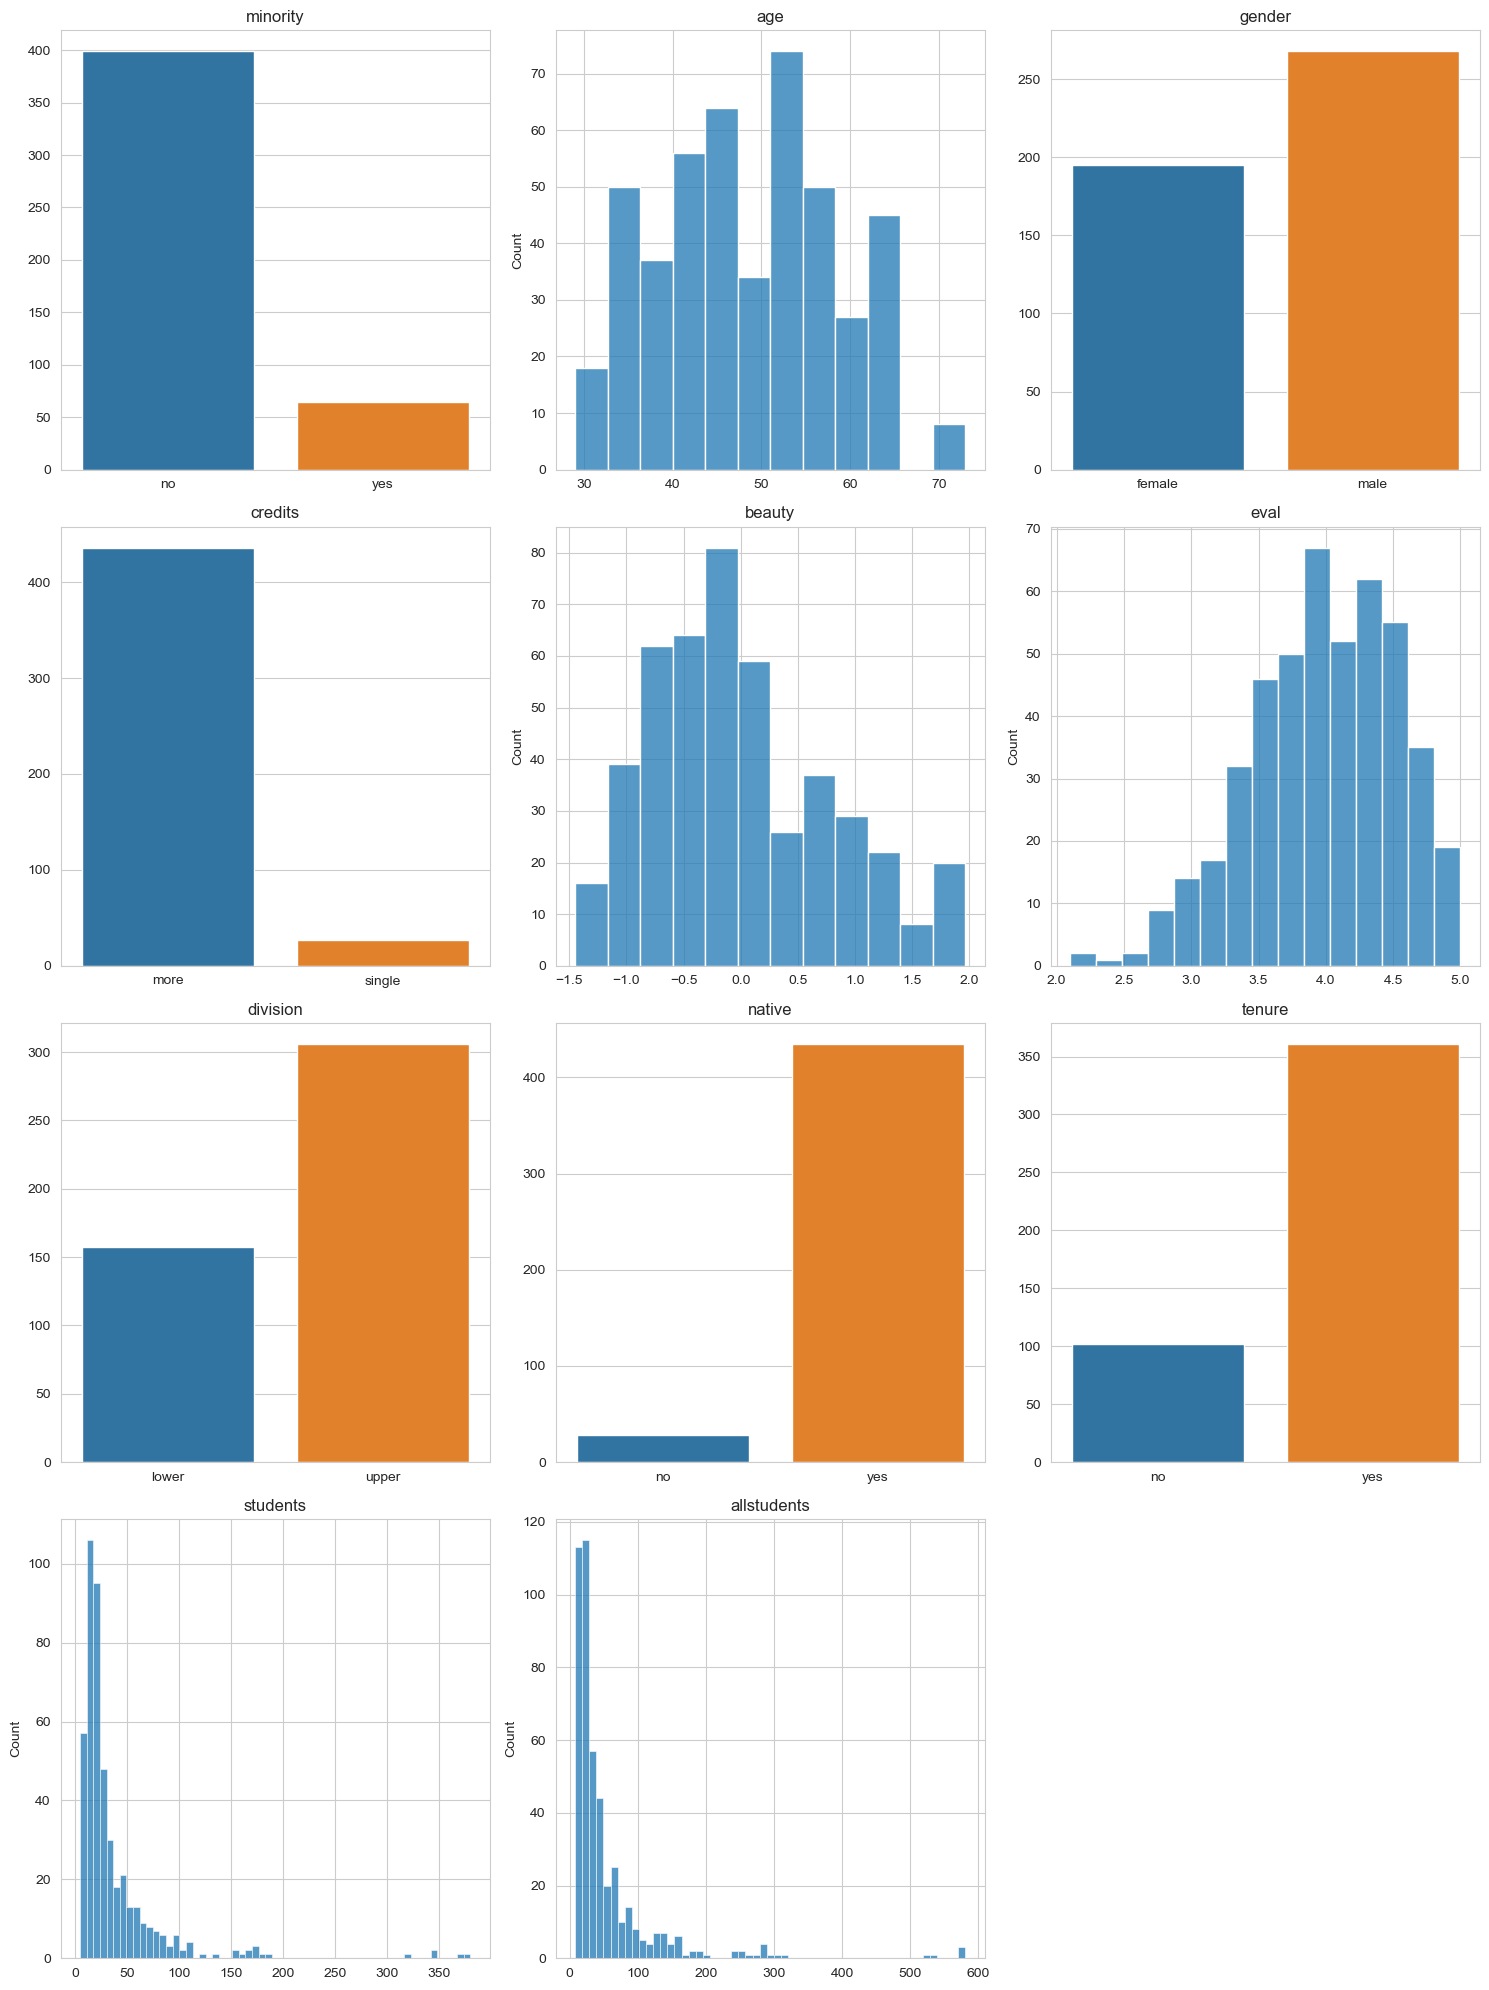

In [4]:
number_features = df.columns.size - 1
grid_rows = int(np.ceil(number_features / 3))
fig, axs = plt.subplots(grid_rows, 3, figsize=(15, 5 * grid_rows))

for ax, feature in zip(axs.flatten(), df.columns[:number_features]):
    if df[feature].dtype == 'O':
        labels, sizes = np.unique(df[feature], return_counts=True)
        sns.barplot(x=labels, y=sizes, hue=labels, ax=ax, legend=False)
        ax.set_xlabel("")
        ax.set_title(feature)
    else:
        sns.histplot(data=df, x=feature, ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)

for ax in axs.flatten()[number_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Analysis

### Does the average beauty score vary by gender?

gender
female    0.25
male     -0.03
Name: beauty, dtype: float64


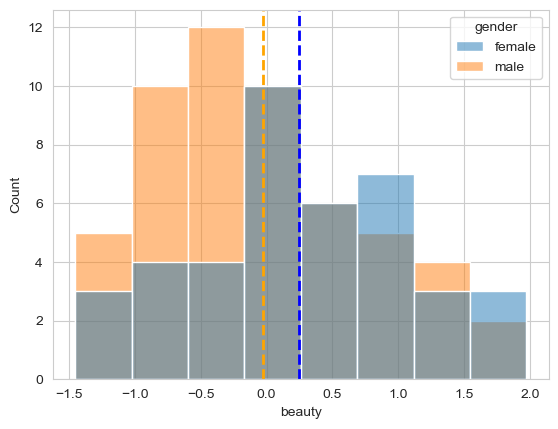

In [5]:
df_subset = df.drop_duplicates(subset=['prof'])
gender_beauty_mean = df_subset.groupby('gender')["beauty"].mean().round(2)
print(gender_beauty_mean)

plt.figure()
sns.histplot(data=df_subset, x="beauty", hue="gender")
plt.axvline(gender_beauty_mean["female"], color="blue", linestyle='dashed', linewidth=2)
plt.axvline(gender_beauty_mean["male"], color="orange", linestyle='dashed', linewidth=2)
plt.show()

### What is the percentage of males and females that are tenured professors?

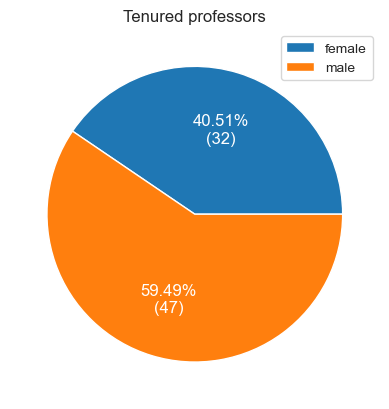

In [6]:
gender_tenure_count = df[df.tenure == 'yes'].drop_duplicates(subset=['prof']).groupby('gender')["tenure"].count()
labels = gender_tenure_count.keys()
sizes = gender_tenure_count.values

fig, ax = plt.subplots()
ax.pie(sizes, textprops={'color': "w", 'fontsize': '12'}, autopct=lambda pct: "{:.2f}%\n({:d})".format(pct, round(pct/100 * sum(sizes))))
ax.legend(labels)
ax.set_title("Tenured professors")
plt.show()

### What is the percentage of professors from minority and non-minority groups that are tenured?

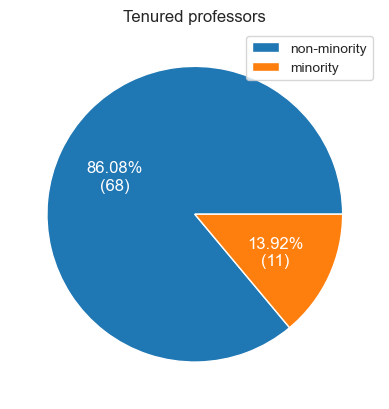

In [7]:
minority_tenure_count = df[df.tenure == 'yes'].drop_duplicates(subset=['prof']).groupby('minority')["tenure"].count()
labels = ["non-minority" if i == "no" else "minority" for i in minority_tenure_count.keys()]
sizes = minority_tenure_count.values

fig, ax = plt.subplots()
ax.pie(sizes, textprops={'color': "w", 'fontsize': '12'}, autopct=lambda pct: "{:.2f}%\n({:d})".format(pct, round(pct/100 * sum(sizes))))
ax.legend(labels)
plt.title("Tenured professors")
plt.show()

### Does the average age vary by tenure?

tenure
no     49.27
yes    47.23
Name: age, dtype: float64


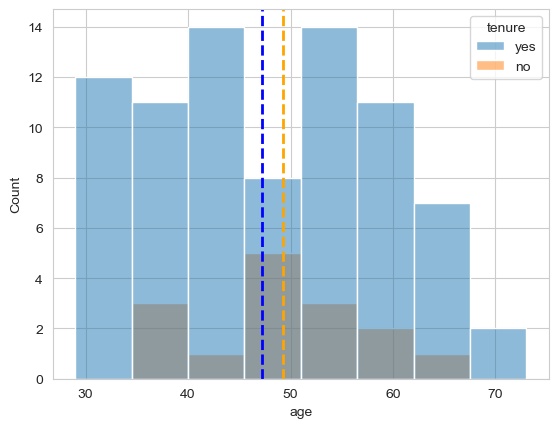

In [8]:
df_subset = df.drop_duplicates(subset=['prof'])
tenure_age_mean = df_subset.groupby('tenure')["age"].mean().round(2)
print(tenure_age_mean)

plt.figure()
sns.histplot(data=df_subset, x="age", hue="tenure")
plt.axvline(tenure_age_mean["yes"], color="blue", linestyle="dashed", linewidth=2)
plt.axvline(tenure_age_mean["no"], color="orange", linestyle="dashed", linewidth=2)
plt.show()

### What is the average evaluation score for tenured professors?

tenure
no     4.13
yes    3.96
Name: eval, dtype: float64


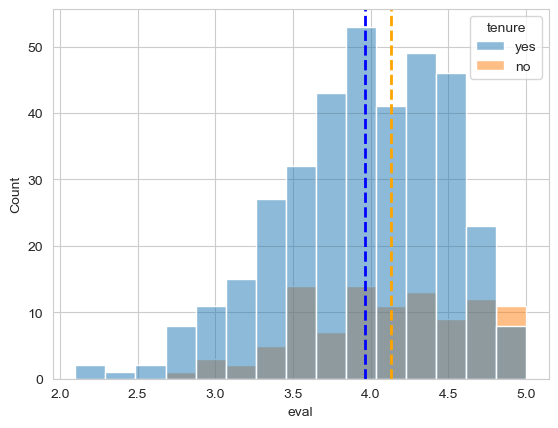

In [9]:
tenure_eval_mean = df.groupby('tenure')["eval"].mean().round(2)
print(tenure_eval_mean)

plt.figure()
sns.histplot(data=df, x="eval", hue="tenure")
plt.axvline(tenure_eval_mean["yes"], color="blue", linestyle="dashed", linewidth=2)
plt.axvline(tenure_eval_mean["no"], color="orange", linestyle="dashed", linewidth=2)
plt.show()

### Do instructors teaching lower-division courses receive higher average teaching evaluations?

division
lower    4.09
upper    3.95
Name: eval, dtype: float64


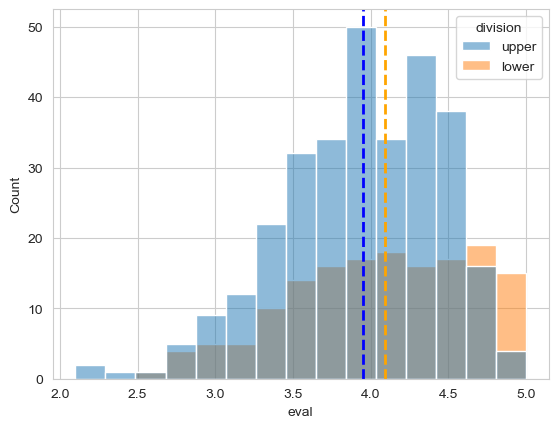

In [10]:
division_eval_mean = df.groupby('division')["eval"].mean().round(2)
print(division_eval_mean)

plt.figure()
sns.histplot(data=df, x="eval", hue="division")
plt.axvline(division_eval_mean["lower"], color="orange", linestyle="dashed", linewidth=2)
plt.axvline(division_eval_mean["upper"], color="blue", linestyle="dashed", linewidth=2)
plt.show()

### Do beauty scores vary by course credits?

         mean   std   min   25%   50%   75%   max
credits                                          
more     0.02  0.80 -1.45 -0.66 -0.07  0.56  1.97
single  -0.27  0.58 -0.66 -0.58 -0.53 -0.29  1.15


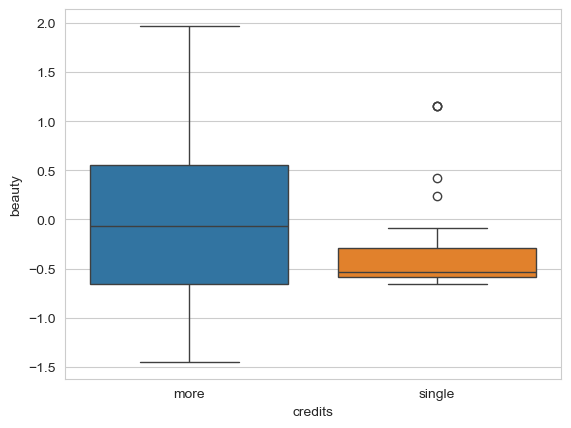

In [11]:
print(df.groupby('credits')["beauty"].describe().round(2).iloc[:, 1:])

plt.figure()
sns.boxplot(x="credits", y='beauty', hue="credits", data=df)
plt.show()

### What is the number of courses taught by gender?

gender
male      268
female    195
Name: count, dtype: int64


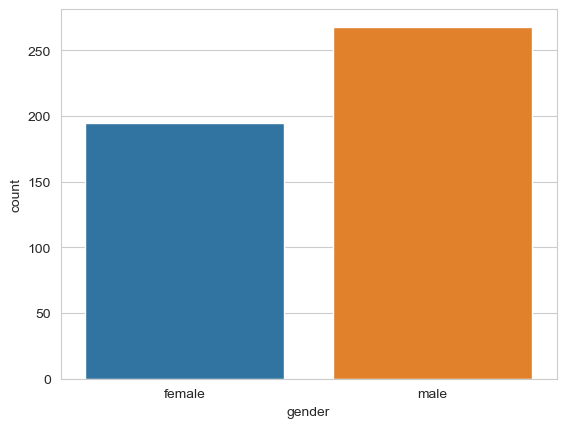

In [12]:
courses_gender_count = df["gender"].value_counts()
print(courses_gender_count)

plt.figure()
sns.countplot(data=df, x="gender", hue="gender")
plt.show()

### What is the number of professors by gender and tenure?

gender  tenure
female  yes       32
        no         8
male    yes       47
        no         7
Name: count, dtype: int64


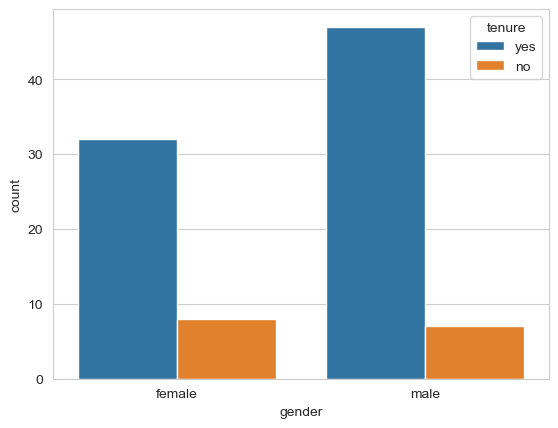

In [13]:
df_subset = df.drop_duplicates(subset=['prof'])
gender_tenure_count = df_subset.groupby("gender")["tenure"].value_counts()
print(gender_tenure_count)

plt.figure()
sns.countplot(data=df_subset, x="gender", hue="tenure")
plt.show()

### Does the average evaluation score vary by gender?

gender
female    3.90
male      4.07
Name: eval, dtype: float64


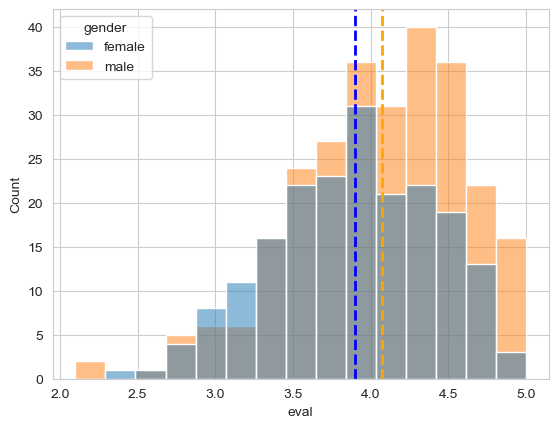

In [14]:
gender_eval_mean = df.groupby('gender')["eval"].mean().round(2)
print(gender_eval_mean)

plt.figure()
sns.histplot(data=df, x="eval", hue="gender")
plt.axvline(gender_eval_mean["female"], color="blue", linestyle='dashed', linewidth=2)
plt.axvline(gender_eval_mean["male"], color="orange", linestyle='dashed', linewidth=2)
plt.show()

### What is the average age by gender?

gender
female    44.95
male      49.48
Name: age, dtype: float64


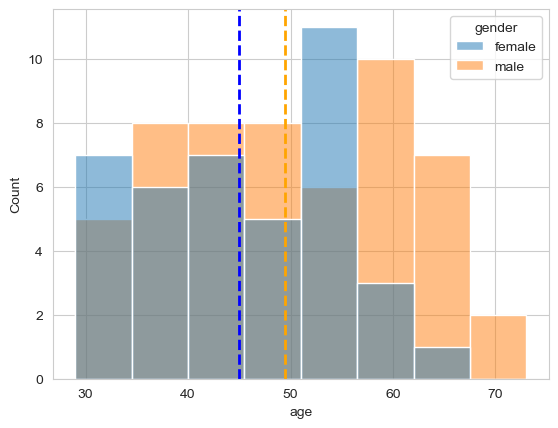

In [15]:
df_subset = df.drop_duplicates(subset=['prof'])
gender_eval_mean = df_subset.groupby('gender')["age"].mean().round(2)
print(gender_eval_mean)

plt.figure()
sns.histplot(data=df_subset, x="age", hue="gender")
plt.axvline(gender_eval_mean["female"], color="blue", linestyle='dashed', linewidth=2)
plt.axvline(gender_eval_mean["male"], color="orange", linestyle='dashed', linewidth=2)
plt.show()

### What is the average age by gender and tenure?

                mean    std   min    25%   50%    75%   max
tenure gender                                              
no     female  48.88   7.14  38.0  45.00  51.0  53.00  57.0
       male    49.71   8.56  37.0  46.00  48.0  54.00  63.0
yes    female  43.97   9.16  29.0  35.75  43.0  51.25  62.0
       male    49.45  11.19  32.0  40.50  50.0  59.50  73.0


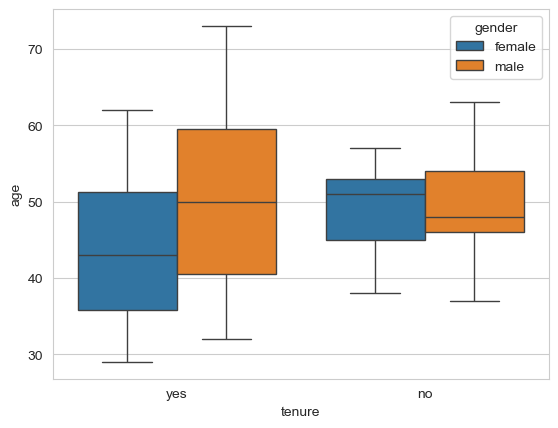

In [16]:
df_subset = df.drop_duplicates(subset=['prof'])
print(df_subset.groupby(['tenure', "gender"])["age"].describe().round(2).iloc[:, 1:])

plt.figure()
sns.boxplot(x="tenure", y="age", hue="gender", data=df_subset)
plt.show()

### Do native professors have higher beauty scores?

native
no    -0.09
yes    0.10
Name: beauty, dtype: float64


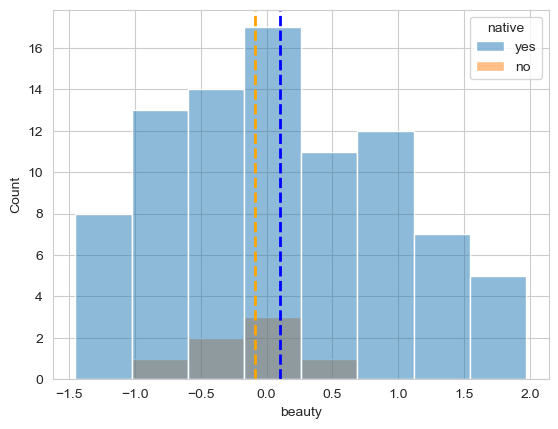

In [17]:
df_subset = df.drop_duplicates(subset=['prof'])
native_beauty_mean = df_subset.groupby('native')["beauty"].mean().round(2)
print(native_beauty_mean)

plt.figure()
sns.histplot(data=df_subset, x="beauty", hue="native")
plt.axvline(native_beauty_mean["yes"], color="blue", linestyle="dashed", linewidth=2)
plt.axvline(native_beauty_mean["no"], color="orange", linestyle="dashed", linewidth=2)
plt.show()

### What is the average age of professors from minority and non-minority groups?

           mean    std   min    25%   50%    75%   max
minority                                              
no        48.24  10.43  31.0  39.00  49.0  57.00  73.0
yes       42.83   7.73  29.0  35.75  43.5  47.75  54.0


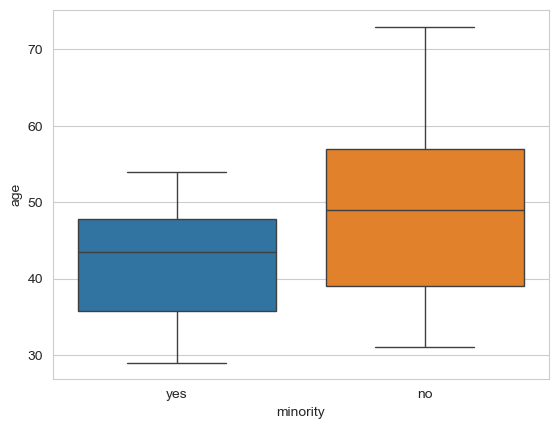

In [18]:
df_subset = df.drop_duplicates(subset=['prof'])
print(df_subset.groupby(["minority"])["age"].describe().round(2).iloc[:, 1:])

plt.figure()
sns.boxplot(x="minority", y="age", hue="minority", data=df_subset)
plt.show()

### What is the number of professors by gender from minority and non-minority groups?

gender  minority
female  no          32
        yes          8
male    no          50
        yes          4
Name: count, dtype: int64


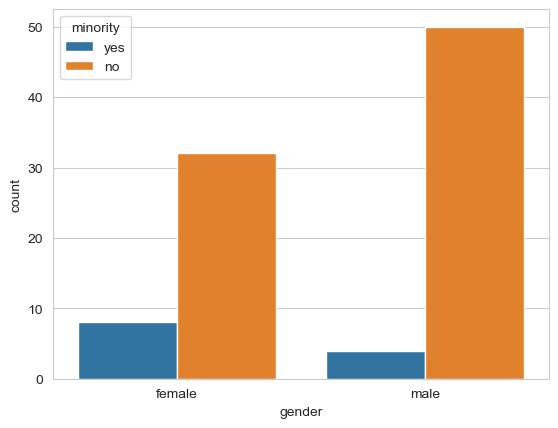

In [19]:
df_subset = df.drop_duplicates(subset=['prof'])
gender_minority_count = df_subset.groupby("gender")["minority"].value_counts()
print(gender_minority_count)

plt.figure()
sns.countplot(data=df_subset, x="gender", hue="minority")
plt.show()

### What is the probability of receiving an evaluation score greater than 4.5?

mean    4.00
std     0.55
min     2.10
25%     3.60
50%     4.00
75%     4.40
max     5.00
Name: eval, dtype: float64

Probability = 18.17%


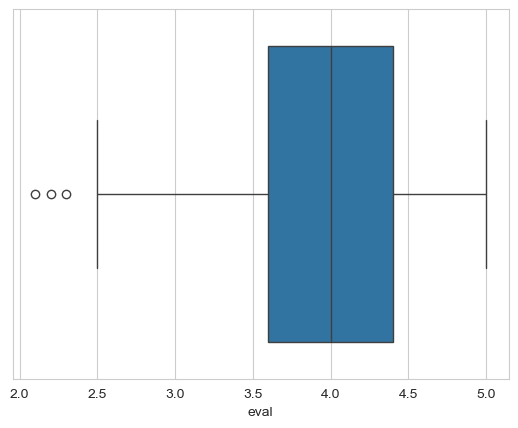

In [20]:
eval_statistics = df["eval"].describe().round(2).iloc[1:]
probability = norm.cdf((4.5 - eval_statistics["mean"]) / eval_statistics["std"])
print(eval_statistics)
print("\n\033[1mProbability\033[0m = {:.2f}%".format(100*(1 - probability)))

plt.figure()
sns.boxplot(x='eval', data=df)
plt.show()

### What is the probability of receiving an evaluation score greater than 3.5 and less than 4.2?

In [21]:
probability_1 = norm.cdf((3.5 - eval_statistics["mean"]) / eval_statistics["std"])
probability_2 = norm.cdf((4.2 - eval_statistics["mean"]) / eval_statistics["std"])
print("\033[1mProbability\033[0m = {:.2f}%".format(100*(probability_2 - probability_1)))

Probability = 46.03%


### Using t-test, does gender affect teaching evaluation scores?

For the **t-test** for independent samples, the following assumptions must be met:

* One independent, categorical variable with two levels or groups.
* One dependent continuous variable.
* There is no relationship between the observations in each group.
* The dependent variable must follow a normal distribution.
* Assumption of homogeneity of variance.

State the hypothesis:

* $H_0: µ_1 = µ_2$ (There is no difference in evaluation scores between male and females)
* $H_1: µ_1 ≠ µ_2$ (There is a difference in evaluation scores between male and females)

In [22]:
df.groupby("gender")["eval"].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,195.0,3.901026,0.538803,2.3,3.6,3.90,4.3,4.9
male,268.0,4.069030,0.556652,2.1,3.7,4.15,4.5,5.0


Use the Levene's test to test the null hypothesis that all input samples are from populations with equal variances.

In [23]:
levene(df[df['gender'] == 'female']['eval'], 
       df[df['gender'] == 'male']['eval'], 
       center='mean')

LeveneResult(statistic=np.float64(0.19032922435292574), pvalue=np.float64(0.6628469836244741))

Since the p-value is greater than 0.05, we can assume equality of variance.

In [24]:
ttest_ind(df[df['gender'] == 'female']['eval'], 
          df[df['gender'] == 'male']['eval'], 
          equal_var=True)

TtestResult(statistic=np.float64(-3.249937943510772), pvalue=np.float64(0.0012387609449522217), df=np.float64(461.0))

**Answer**: Since the p-value is less than 0.05, we can reject the null hypothesis as there is enough proof that there is a statistical difference in teaching evaluations based on gender.

### Using ANOVA test, do beauty scores vary by age?

The data must be grouped into categories as the one-way ANOVA can't work with continuous variable, then the categories will be professors that are:

* 40 years and younger.
* Between 40 and 60 years.
* 60 years and older.

State the hypothesis:

* $H_0: µ_1 = µ_2 = µ_3$ (The three population means are equal)
* $H_1:$ At least one of the means differ.

In [25]:
df.loc[(df['age'] <= 40), 'age_group'] = '40 years and younger'
df.loc[(df['age'] > 40) & (df['age'] < 60), 'age_group'] = 'between 40 and 60 years'
df.loc[(df['age'] >= 60), 'age_group'] = '60 years and older'

In [26]:
df.groupby("age_group")["beauty"].describe()

,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
40 years and younger,113.0,0.336196,0.913748,-1.450494,-0.326015,0.289916,1.070944,1.970023
60 years and older,77.0,-0.423557,0.548289,-1.422919,-0.733091,-0.395397,-0.056677,0.588569
between 40 and 60 years,273.0,-0.019693,0.728354,-1.090389,-0.583587,-0.083601,0.420400,1.774334


Test for equality of variance.

In [27]:
levene(df[df['age_group'] == '40 years and younger']['beauty'],
       df[df['age_group'] == 'between 40 and 60 years']['beauty'],
       df[df['age_group'] == '60 years and older']['beauty'], 
       center='mean')

LeveneResult(statistic=np.float64(11.769735544673434), pvalue=np.float64(1.0350399938234537e-05))

Since the p-value is less than 0.05, the variances are not equal.

In [28]:
f_oneway(df[df['age_group'] == '40 years and younger']['beauty'], 
         df[df['age_group'] == 'between 40 and 60 years']['beauty'], 
         df[df['age_group'] == '60 years and older']['beauty'])

F_onewayResult(statistic=np.float64(23.552552376353074), pvalue=np.float64(1.8271127151948056e-10))

**Answer**: Since the p-value is less than 0.05, we reject the null hypothesis as there is significant evidence that at least one of the means differs.

### Using ANOVA test, do teaching evaluation scores vary by age?

State the hypothesis:

* $H_0: µ_1 = µ_2 = µ_3$ (The three population means are equal)
* $H_1:$ At least one of the means differ.

In [29]:
df.groupby("age_group")["eval"].describe()

,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
40 years and younger,113.0,4.002655,0.505763,2.7,3.6,4.1,4.4,4.8
60 years and older,77.0,3.894805,0.626371,2.2,3.4,4.0,4.4,4.9
between 40 and 60 years,273.0,4.025641,0.551537,2.1,3.7,4.0,4.5,5.0


In [30]:
levene(df[df['age_group'] == '40 years and younger']['eval'],
       df[df['age_group'] == 'between 40 and 60 years']['eval'],
       df[df['age_group'] == '60 years and older']['eval'], 
       center='mean')

LeveneResult(statistic=np.float64(3.123930368994838), pvalue=np.float64(0.04491850441786862))

In [31]:
f_oneway(df[df['age_group'] == '40 years and younger']['eval'], 
         df[df['age_group'] == 'between 40 and 60 years']['eval'], 
         df[df['age_group'] == '60 years and older']['eval'])

F_onewayResult(statistic=np.float64(1.6792657352642264), pvalue=np.float64(0.1876521827204442))

**Answer**: Since the p-value is greater than 0.05, we cannot reject the null hypothesis as there is no significant evidence that at least one of the means differs.

### Using chi-square, is there an association between tenure and gender?

State the hypothesis:

* $H_0:$ The proportion of professors who are tenured is independent of gender.
* $H_1:$ The proportion of professors who are tenured is associated with gender.

In [32]:
cross_tenure_gender = pd.crosstab(df['tenure'], df['gender'])
cross_tenure_gender

gender,female,male
tenure,,
no,50,52
yes,145,216


In [33]:
chi2_contingency(cross_tenure_gender, correction=False)

Chi2ContingencyResult(statistic=np.float64(2.557051129789522), pvalue=np.float64(0.10980322511302845), dof=1, expected_freq=array([[ 42.95896328,  59.04103672],
       [152.04103672, 208.95896328]]))

**Answer**: Since the p-value is greater than 0.05, we cannot reject the null hypothesis as there is no sufficient evidence that professors are tenured as a result of gender.

### Using Pearson correlation, is teaching evaluation score correlated with beauty score?

State the hypothesis:

* $H_0:$ Teaching evaluation score is not correlated with beauty score.
* $H_1:$ Teaching evaluation score is correlated with beauty score.

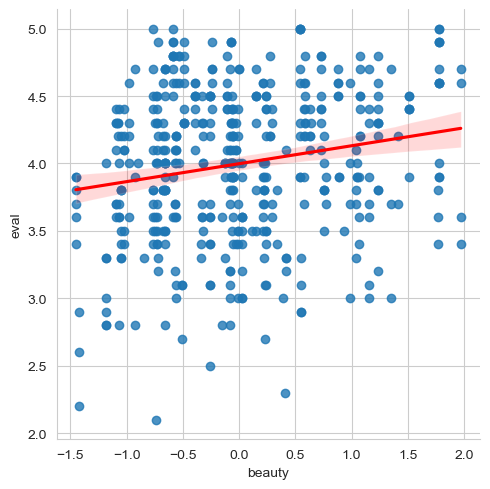

In [34]:
sns.lmplot(data=df, x="beauty", y="eval", line_kws={"color": "red"})
plt.show()

In [35]:
pearsonr(df['beauty'], df['eval'])

PearsonRResult(statistic=np.float64(0.18903909084045212), pvalue=np.float64(4.247115419813557e-05))

**Answer**: Since the p-value is less than 0.05, we reject the null hypothesis as there exists a relationship between beauty and teaching evaluation score.

### Using t-test, does tenure affect teaching evaluation scores?

State the hypothesis

* $H_0: µ_1 = µ_2$ (There is no difference in evaluation scores between tenure and non-tenure)
* $H_1: µ_1 ≠ µ_2$ (There is a difference in evaluation scores between tenure and non-tenure)

In [36]:
df.groupby("tenure")["eval"].describe()

,count,mean,std,min,25%,50%,75%,max
tenure,,,,,,,,
no,102.0,4.133333,0.556747,2.8,3.7,4.2,4.6,5.0
yes,361.0,3.960111,0.549104,2.1,3.6,4.0,4.4,5.0


In [37]:
ttest_ind(df[df['tenure'] == 'yes']['eval'],
          df[df['tenure'] == 'no']['eval'],
          equal_var=True)

TtestResult(statistic=np.float64(-2.8046798258451777), pvalue=np.float64(0.005249471210198792), df=np.float64(461.0))

**Answer**: Since the p-value is less than 0.05, we reject the null hypothesis as there evidence that being tenured affects teaching evaluation scores.

### Using chi-square, is there an association between age and tenure?

State the hypothesis:

* $H_0:$ There is no association between age and tenure.
* $H_1:$ There is an association between age and tenure.

In [38]:
cross_tenure_age = pd.crosstab(df['tenure'], df['age_group'])
cross_tenure_age

age_group,40 years and younger,60 years and older,between 40 and 60 years
tenure,,,
no,15,7,80
yes,98,70,193


In [39]:
chi2_contingency(cross_tenure_age, correction=True)

Chi2ContingencyResult(statistic=np.float64(20.957740803528935), pvalue=np.float64(2.8124473945785386e-05), dof=2, expected_freq=array([[ 24.89416847,  16.96328294,  60.1425486 ],
       [ 88.10583153,  60.03671706, 212.8574514 ]]))

**Answer**: Since the p-value is less than 0.05, we reject the null hypothesis as there is evidence of an association between age and tenure.

### Using chi-square, is there an association between visible minorities and tenure?

State the hypothesis:

* $H_0:$ There is no association between tenure and visible minorities.
* $H_1:$ There is an association between tenure and visible minorities.

In [40]:
cross_minority_tenure = pd.crosstab(df['minority'], df['tenure'])
cross_minority_tenure

tenure,no,yes
minority,,
no,92,307
yes,10,54


In [41]:
chi2_contingency(cross_minority_tenure, correction=True)

Chi2ContingencyResult(statistic=np.float64(1.3675127484429763), pvalue=np.float64(0.24223968800237178), dof=1, expected_freq=array([[ 87.90064795, 311.09935205],
       [ 14.09935205,  49.90064795]]))

**Answer**: Since the p-value is greater than 0.05, we cannot reject the null hypothesis as there is no evidence of an association between visible minorities and tenure.

### Using regression with t-test, does gender affect teaching evaluation scores?

State the hypothesis:

* $H_0: β_1$ = 0 (Gender has no effect on teaching evaluation scores)
* $H_1: β_1$ is not equal to 0 (Gender has an effect on teaching evaluation scores)

In [42]:
# X is the input variables (or independent variables)
X = df['gender'].map({"female": 1, "male": 0})

# y is the target/dependent variable
y = df['eval']

# Add an intercept (beta_0) to our model
X = sm.add_constant(X) 

# Ordinary Least Squares
model = sm.OLS(y, X).fit() 

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   eval   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     10.56
Date:                Thu, 29 May 2025   Prob (F-statistic):            0.00124
Time:                        02:23:20   Log-Likelihood:                -378.50
No. Observations:                 463   AIC:                             761.0
Df Residuals:                     461   BIC:                             769.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0690      0.034    121.288      0.000       4.003       4.135
gender        -0.1680      0.052     -3.250      0.001      -0.270      -0.066
==============================================================================
Omnibus:                       17.625   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.970
Skew:                          -0.496   Prob(JB):                     7.60e-05
Kurtosis:                       2.981   Cond. No.                         2.47
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Answer**: Since the p-value is less than 0.05, we reject the null hypothesis as there is evidence that there is a difference in mean evaluation scores based on gender. The coefficient -0.1680 means that females get 0.168 scores less than men.

### Using regression with ANOVA, do beauty scores vary by age?

State the hypothesis:

* $H_0: µ_1 = µ_2 = µ_3$ (The three population means are equal)
* $H_1:$ At least one of the means differ.

In [43]:
model = ols('beauty ~ age_group', data=df).fit()
anova_table = sm.stats.anova_lm(model)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
age_group,2.0,26.691809,13.345905,23.552552,1.827113e-10
Residual,460.0,260.656087,0.566644,NaN,NaN


**Answer**: Since the p-value is less than 0.05, we reject the null hypothesis as there is significant evidence that at least one of the means differs.

### Using regression with t-test, does tenure affect beauty scores?

State the hypothesis:

* $H_0:$ The average beauty scores for tenured and non-tenured instructors are equal.
* $H_1:$ There is a difference in the average beauty scores for tenured and non-tenured instructors.

In [44]:
# X is the input variables (or independent variables)
X = df['tenure'].map({"yes": 1, "no": 0})

# y is the target/dependent variable
y = df['beauty']

# Add an intercept (beta_0) to our model
X = sm.add_constant(X) 

# Ordinary Least Squares
model = sm.OLS(y, X).fit() 

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 beauty   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.1689
Date:                Thu, 29 May 2025   Prob (F-statistic):              0.681
Time:                        02:23:20   Log-Likelihood:                -546.45
No. Observations:                 463   AIC:                             1097.
Df Residuals:                     461   BIC:                             1105.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0284      0.078      0.363      0.717      -0.125       0.182
tenure        -0.0364      0.089     -0.411      0.681      -0.210       0.138
==============================================================================
Omnibus:                       23.184   Durbin-Watson:                   0.461
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.229
Skew:                           0.507   Prob(JB):                     9.03e-06
Kurtosis:                       2.583   Cond. No.                         4.05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Answer**: Since the p-value is greater than 0.05, we cannot reject the null hypothesis as there is no evidence that the mean difference of tenured and untenured instructors are different.

### Using regression with t-test, are more students assigned to native professors?

State the hypothesis:

* $H_0:$ The average number of students assigned to native english speakers vs non-native english speakers are equal.
* $H_1:$ There is a difference in the average number of students assigned to native english speakers vs non-native English speakers.

In [45]:
# X is the input variables (or independent variables)
X = df["native"].map({"yes": 1, "no": 0})

# y is the target/dependent variable
y = df['allstudents']

# Add an intercept (beta_0) to our model
X = sm.add_constant(X) 

# Ordinary Least Squares
model = sm.OLS(y, X).fit() 

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            allstudents   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     3.476
Date:                Thu, 29 May 2025   Prob (F-statistic):             0.0629
Time:                        02:23:20   Log-Likelihood:                -2654.2
No. Observations:                 463   AIC:                             5312.
Df Residuals:                     461   BIC:                             5321.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.6071     14.150      2.092      0.037       1.802      57.413
native        27.2158     14.598      1.864      0.063      -1.471      55.902
==============================================================================
Omnibus:                      429.792   Durbin-Watson:                   0.708
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10527.126
Skew:                           4.129   Prob(JB):                         0.00
Kurtosis:                      24.852   Cond. No.                         8.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Answer**: Since the p-value is greater than 0.05, we cannot reject the null hypothesis as there is no evidence that being a native english speaker or a non-native english speaker affects the number of students assigned.